In [4]:
import osmnx as ox
import networkx as nx
import pandas as pd
import time

In [6]:
# -----------------------------------
# 1️⃣ Bombay/Mumbai Bounding Box
# -----------------------------------
# left, bottom, right, top
west  = 72.75
south = 18.85
east  = 73.40
north = 20.05

# west = 72.7752
# south = 18.8928
# east = 72.9865
# north = 19.2711


print("Downloading Mumbai road network...")
G = ox.graph_from_bbox((west, south, east, north), network_type="drive")
print("Road network downloaded successfully!\n")

# -----------------------------------
# 2️⃣ Extract Hospitals Around Mumbai
# -----------------------------------
print("Extracting train stations from OpenStreetMap...")

tags = {"railway": "station"}

# correct function for your OSMnx version
pois = ox.features_from_bbox((west, south, east, north), tags)

# keep only those with a name
pois = pois[["name", "geometry"]].dropna()

# convert to lat/lon
pois["latitude"] = pois.geometry.centroid.y
pois["longitude"] = pois.geometry.centroid.x

print(f"{len(pois)} stations found!\n")

# Optional: Save dataset
pois[["name", "latitude", "longitude"]].to_csv("railway_mumbai.csv", index=False)
ox.save_graphml(G, "mumbai_graph.graphml")

print("Saved Mumbai City Geography Dataset")

Road network downloaded successfully!

Saved Mumbai City Geography Dataset


In [2]:
pois = pd.read_csv("railway_mumbai.csv")
G = ox.load_graphml("mumbai_graph.graphml")

Train Stations:

0. Vasai Road
1. Naigaon
2. Bhayandar
3. Kharbhav
4. Palghar
5. Bhivandi Road
6. Dahisar
7. Santa Cruz
8. Thane
9. Ambivli
10. Titwala
11. Khadavli
12. Vithalwadi
13. Ambernath
14. Badlapur
15. Khar Road
16. Chikhale
17. Apta
18. Vaitarna
19. Saphale
20. Kalva
21. Kanjur Marg
22. Vidyavihar
23. Lower Parel
24. Diva Junction
25. Grant Road
26. Chembur
27. Bhakti Park
28. Wadala Depot
29. Karjat
30. Neral
31. Palasdhari
32. Sewri
33. Cotton Green
34. Asangaon
35. Atgaon
36. Khardi
37. Vasind
38. Chowk
39. Bhivpuri Road
40. Shelu
41. Umroli
42. Boisar
43. Kelve Road
44. Mumbra
45. Dativali
46. Mansarovar
47. Mysore Colony
48. Mulund
49. Khandeshwar
50. King's Circle
51. Matheran
52. Jumma Patti
53. Water Pipe
54. Shahad
55. Sandhurst Road
56. Thakurli
57. Dockyard Road
58. Reay Road
59. Currey Road
60. Chembur
61. Aman Lodge
62. Mankhurd
63. Nahur
64. Bandra
65. Byculla
66. Charni Road
67. Dadar
68. Dadar
69. Mahim Junction
70. Marine Lines
71. Mumbai Central
72. Panvel
7

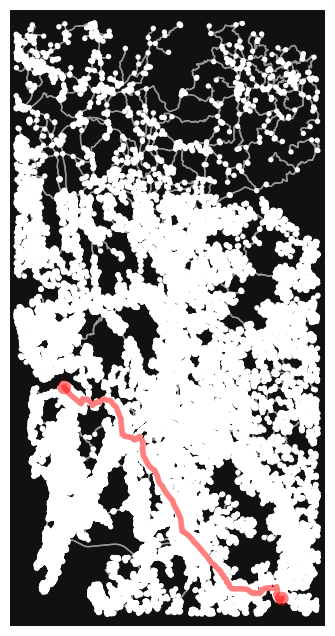

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
# -----------------------------------
# 3️⃣ Display Train Station List to User
# -----------------------------------
pois = pois.reset_index(drop=True)

print("Train Stations:\n")
for i, name in enumerate(pois["name"]):
    print(f"{i}. {name}")

source_index = int(input("\nSelect source (number): "))
dest_index = int(input("Select destination (number): "))

source = pois.iloc[source_index]
dest = pois.iloc[dest_index]

# -----------------------------------
# 4️⃣ Map to Graph Nodes
# -----------------------------------
orig_node = ox.distance.nearest_nodes(G, source["longitude"], source["latitude"])
dest_node = ox.distance.nearest_nodes(G, dest["longitude"], dest["latitude"])

# -----------------------------------
# 5️⃣ Run Dijkstra Algorithm
# -----------------------------------
print("\nRunning Dijkstra Algorithm...")
start_time = time.time()

route = nx.shortest_path(G, orig_node, dest_node, weight="length")

end_time = time.time()
distance = nx.shortest_path_length(G, orig_node, dest_node, weight="length")

print("\nShortest Distance: {:.2f} meters".format(distance))
print("Execution Time: {:.4f} seconds".format(end_time - start_time))

# -----------------------------------
# 6️⃣ Plot Route
# -----------------------------------
print("\nDisplaying route on map...")
ox.plot_graph_route(G, route)

# Cleaning Local Train Dataset

In [12]:
df = pd.read_csv('Mumbai Local Train Dataset.csv', encoding="latin1")
df = df [["Station","Station Code","Line","Distance From Previous of the Line","Time taken From Previous of the Line"]]
display(df)

df["Distance From Previous of the Line"] = (
    df["Distance From Previous of the Line"]
    .str.replace(" KM", "", regex=False)
    .astype(float)
)

df["Time taken From Previous of the Line"] = (
    df["Time taken From Previous of the Line"]
    .str.replace(" min", "", regex=False)
    .astype(float)
)

display(df)

df.to_csv('Cleaned Local Train Dataset.csv')

,Station,Station Code,Line,Distance From Previous of the Line,Time taken From Previous of the Line
0,Churchgate,CCG,Western,0 KM,0 min
1,Marine Lines,MEL,Western,1 KM,3 min
2,Charni Road,CYR,Western,1 KM,2 min
3,Grant Road,GTR,Western,1 KM,3 min
4,Mumbai Central,MMCT,Western,1 KM,2 min
...,...,...,...,...,...
197,Neral,NRL,Neral-Matheran,0 KM,0 min
198,Jumapatti,JTT,Neral-Matheran,5 KM,46 min
199,Waterpipe,WTP,Neral-Matheran,6 KM,46 min
200,Aman Lodge,AMNA,Neral-Matheran,7 KM,50 min


,Station,Station Code,Line,Distance From Previous of the Line,Time taken From Previous of the Line
0,Churchgate,CCG,Western,0.0,0.0
1,Marine Lines,MEL,Western,1.0,3.0
2,Charni Road,CYR,Western,1.0,2.0
3,Grant Road,GTR,Western,1.0,3.0
4,Mumbai Central,MMCT,Western,1.0,2.0
...,...,...,...,...,...
197,Neral,NRL,Neral-Matheran,0.0,0.0
198,Jumapatti,JTT,Neral-Matheran,5.0,46.0
199,Waterpipe,WTP,Neral-Matheran,6.0,46.0
200,Aman Lodge,AMNA,Neral-Matheran,7.0,50.0


# Create The Mapping

In [14]:
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import re
from difflib import get_close_matches

# -------------------------------------------------
# 1️⃣ Normalization Function
# -------------------------------------------------
def normalize(name):
    name = str(name).lower().strip()
    name = re.sub(r"\(.*?\)", "", name)
    name = name.replace("junction", "")
    name = name.replace("jn", "")
    name = re.sub(r"\s+", " ", name)
    return name.strip()

# -------------------------------------------------
# 2️⃣ Load Rail Dataset
# -------------------------------------------------
df = pd.read_csv("Cleaned Local Train Dataset.csv")
df["station_clean"] = df["Station"].apply(normalize)

# -------------------------------------------------
# 3️⃣ Build Rail Graph (Topology Only)
# -------------------------------------------------
G_rail = nx.Graph()

for _, row in df.iterrows():
    G_rail.add_node(row["station_clean"], original=row["Station"])

for line, group in df.groupby("Line", sort=False):
    group = group.reset_index(drop=True)

    for i in range(1, len(group)):
        prev_station = group.loc[i - 1, "station_clean"]
        curr_station = group.loc[i, "station_clean"]
        distance = group.loc[i, "Distance From Previous of the Line"]

        G_rail.add_edge(
            prev_station,
            curr_station,
            weight=distance,
            line=line
        )

# -------------------------------------------------
# 4️⃣ Load Station Coordinate Dataset
# -------------------------------------------------
pois = pd.read_csv("railway_mumbai.csv").reset_index(drop=True)
pois["station_clean"] = pois["name"].apply(normalize)

poi_lookup = dict(
    zip(
        pois["station_clean"],
        zip(pois["latitude"], pois["longitude"])
    )
)

poi_names = pois["station_clean"].tolist()

# -------------------------------------------------
# 5️⃣ Display Station List
# -------------------------------------------------
print("Train Stations:\n")
for i, name in enumerate(pois["name"]):
    print(f"{i}. {name}")

source_index = int(input("\nSelect source (number): "))
dest_index = int(input("Select destination (number): "))

source_name = normalize(pois.iloc[source_index]["name"])
dest_name = normalize(pois.iloc[dest_index]["name"])

# -------------------------------------------------
# 6️⃣ Compute Rail Shortest Path
# -------------------------------------------------
route_stations = nx.shortest_path(
    G_rail,
    source_name,
    dest_name,
    weight="weight"
)

total_distance = nx.shortest_path_length(
    G_rail,
    source_name,
    dest_name,
    weight="weight"
)

print("\nRail Route:")
for station in route_stations:
    print(station.title())

print("\nTotal Distance:", total_distance, "KM")

# -------------------------------------------------
# 7️⃣ Fuzzy Coordinate Lookup
# -------------------------------------------------
def get_coordinates(station_clean):
    if station_clean in poi_lookup:
        return poi_lookup[station_clean]
    
    match = get_close_matches(station_clean, poi_names, n=1, cutoff=0.8)
    
    if match:
        print(f"Fuzzy matched: {station_clean} → {match[0]}")
        return poi_lookup[match[0]]
    
    print(f"No coordinate match for: {station_clean}")
    return None

# 1️⃣ Plot Mumbai road graph
fig, ax = ox.plot_graph(
    G,
    show=False,
    close=False,
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.5
)

# 2️⃣ Extract rail route coordinates
route_lats = []
route_lons = []

for station in route_stations:
    coords = get_coordinates(station)
    if coords is None:
        continue
    
    lat, lon = coords
    route_lats.append(lat)
    route_lons.append(lon)

# 3️⃣ Plot rail graph edges (straight lines)
ax.plot(
    route_lons,
    route_lats,
    color="blue",
    linewidth=4
)

# 4️⃣ Plot rail nodes
ax.scatter(
    route_lons,
    route_lats,
    c="red",
    s=50,
    zorder=5
)

plt.title("Rail Graph Over Mumbai Road Network")
plt.show()


Train Stations:

0. Vasai Road
1. Naigaon
2. Bhayandar
3. Kharbhav
4. Palghar
5. Bhivandi Road
6. Dahisar
7. Santa Cruz
8. Thane
9. Ambivli
10. Titwala
11. Khadavli
12. Vithalwadi
13. Ambernath
14. Badlapur
15. Khar Road
16. Chikhale
17. Apta
18. Vaitarna
19. Saphale
20. Kalva
21. Kanjur Marg
22. Vidyavihar
23. Lower Parel
24. Diva Junction
25. Grant Road
26. Chembur
27. Bhakti Park
28. Wadala Depot
29. Karjat
30. Neral
31. Palasdhari
32. Sewri
33. Cotton Green
34. Asangaon
35. Atgaon
36. Khardi
37. Vasind
38. Chowk
39. Bhivpuri Road
40. Shelu
41. Umroli
42. Boisar
43. Kelve Road
44. Mumbra
45. Dativali
46. Mansarovar
47. Mysore Colony
48. Mulund
49. Khandeshwar
50. King's Circle
51. Matheran
52. Jumma Patti
53. Water Pipe
54. Shahad
55. Sandhurst Road
56. Thakurli
57. Dockyard Road
58. Reay Road
59. Currey Road
60. Chembur
61. Aman Lodge
62. Mankhurd
63. Nahur
64. Bandra
65. Byculla
66. Charni Road
67. Dadar
68. Dadar
69. Mahim Junction
70. Marine Lines
71. Mumbai Central
72. Panvel
7

NodeNotFound: Source bhivandi road is not in G

Train Stations:

0. Vasai Road
1. Naigaon
2. Palghar
3. Dahisar
4. Thane
5. Ambivli
6. Titwala
7. Khadavli
8. Vithalwadi
9. Ambernath
10. Khar Road
11. Apta
12. Vaitarna
13. Saphale
14. Kalva
15. Kanjur Marg
16. Lower Parel
17. Diva Junction
18. Grant Road
19. Chembur
20. Karjat
21. Neral
22. Palasdhari
23. Sewri
24. Cotton Green
25. Asangaon
26. Khardi
27. Vasind
28. Bhivpuri Road
29. Shelu
30. Boisar
31. Kelve Road
32. Mumbra
33. Dativali
34. Mansarovar
35. Mulund
36. Khandeshwar
37. Matheran
38. Shahad
39. Sandhurst Road
40. Thakurli
41. Reay Road
42. Currey Road
43. Chembur
44. Aman Lodge
45. Mankhurd
46. Nahur
47. Bandra
48. Byculla
49. Charni Road
50. Dadar
51. Dadar
52. Mahim Junction
53. Marine Lines
54. Mumbai Central
55. Panvel
56. Vile Parle
57. Virar
58. Sion
59. Govandi
60. Bhandup
61. Borivali
62. Kandivali
63. Malad
64. Goregaon
65. Prabhadevi
66. Chinchpokli
67. Parel
68. Naigaon
69. Vikhroli
70. Churchgate
71. Matunga
72. Matunga Road
73. Ghatkopar
74. Nalla Sopara
75.

Source: palghar
Destination: kalyan

Rail Route:
Palghar
Kelva Road
Saphale
Vaitarna
Virar
Nalla Sopara
Vasai Road
Juchandra Road
Kaman Road
Kharbao
Bhiwandi Road
Kopar
Dombivli
Thakurli
Kalyan

Total Distance: 73.0 KM
Fuzzy matched coordinates: kelva road → kelve road
No coordinate match for: juchandra road
No coordinate match for: kharbao
No coordinate match for: bhiwandi road


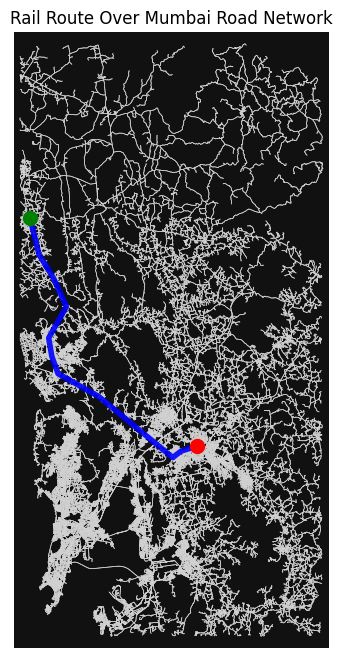

In [16]:
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import re
from difflib import get_close_matches

# -------------------------------------------------
# 1️⃣ Normalization Function
# -------------------------------------------------
def normalize(name):
    name = str(name).lower().strip()
    name = re.sub(r"\(.*?\)", "", name)
    name = name.replace("junction", "")
    name = name.replace("jn", "")
    name = re.sub(r"\s+", " ", name)
    return name.strip()

# -------------------------------------------------
# 2️⃣ Load Rail Dataset
# -------------------------------------------------
df = pd.read_csv("Cleaned Local Train Dataset.csv")
df["station_clean"] = df["Station"].apply(normalize)

# -------------------------------------------------
# 3️⃣ Build Rail Graph
# -------------------------------------------------
G_rail = nx.Graph()

for _, row in df.iterrows():
    G_rail.add_node(row["station_clean"], original=row["Station"])

for line, group in df.groupby("Line", sort=False):
    group = group.reset_index(drop=True)

    for i in range(1, len(group)):
        prev_station = group.loc[i - 1, "station_clean"]
        curr_station = group.loc[i, "station_clean"]
        distance = group.loc[i, "Distance From Previous of the Line"]

        G_rail.add_edge(
            prev_station,
            curr_station,
            weight=distance,
            line=line
        )

rail_nodes = list(G_rail.nodes)

# -------------------------------------------------
# 4️⃣ Load Station Coordinates
# -------------------------------------------------
pois = pd.read_csv("railway_mumbai.csv").reset_index(drop=True)
pois["station_clean"] = pois["name"].apply(normalize)

# Keep only stations that exist in rail graph
pois = pois[pois["station_clean"].isin(rail_nodes)].reset_index(drop=True)

poi_lookup = dict(
    zip(
        pois["station_clean"],
        zip(pois["latitude"], pois["longitude"])
    )
)

poi_names = pois["station_clean"].tolist()

# -------------------------------------------------
# 5️⃣ Safe Rail Node Matching
# -------------------------------------------------
def match_to_rail_node(name_clean):

    if name_clean in G_rail:
        return name_clean

    match = get_close_matches(name_clean, rail_nodes, n=1, cutoff=0.8)

    if match:
        print(f"Fuzzy matched rail node: {name_clean} → {match[0]}")
        return match[0]

    return None

# -------------------------------------------------
# 6️⃣ Coordinate Lookup with Fuzzy Matching
# -------------------------------------------------
def get_coordinates(station_clean):

    if station_clean in poi_lookup:
        return poi_lookup[station_clean]

    match = get_close_matches(station_clean, poi_names, n=1, cutoff=0.8)

    if match:
        print(f"Fuzzy matched coordinates: {station_clean} → {match[0]}")
        return poi_lookup[match[0]]

    print(f"No coordinate match for: {station_clean}")
    return None

# -------------------------------------------------
# 7️⃣ Display Valid Station List
# -------------------------------------------------
print("Train Stations:\n")
for i, name in enumerate(pois["name"]):
    print(f"{i}. {name}")

source_index = int(input("\nSelect source (number): "))
dest_index = int(input("Select destination (number): "))

source_clean = normalize(pois.iloc[source_index]["name"])
dest_clean = normalize(pois.iloc[dest_index]["name"])

source_name = match_to_rail_node(source_clean)
dest_name = match_to_rail_node(dest_clean)

if source_name is None or dest_name is None:
    raise ValueError("Selected station not found in rail network.")

# -------------------------------------------------
# 8️⃣ Compute Rail Shortest Path
# -------------------------------------------------
route_stations = nx.shortest_path(
    G_rail,
    source_name,
    dest_name,
    weight="weight"
)

total_distance = nx.shortest_path_length(
    G_rail,
    source_name,
    dest_name,
    weight="weight"
)

print("Source:",source_name)
print("Destination:",dest_name)

print("\nRail Route:")
for station in route_stations:
    print(station.title())

print("\nTotal Distance:", total_distance, "KM")

# -------------------------------------------------
# 9️⃣ Plot Rail Route Over Mumbai Map
# -------------------------------------------------

# Plot Mumbai road network as background
fig, ax = ox.plot_graph(
    G,
    show=False,
    close=False,
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.5
)

route_lats = []
route_lons = []

for station in route_stations:
    coords = get_coordinates(station)
    if coords is None:
        continue

    lat, lon = coords
    route_lats.append(lat)
    route_lons.append(lon)

# Draw straight rail route
ax.plot(
    route_lons,
    route_lats,
    color="blue",
    linewidth=4,
    alpha=0.9
)

# Highlight source and destination
ax.scatter(route_lons[0], route_lats[0], c="green", s=100, zorder=5)
ax.scatter(route_lons[-1], route_lats[-1], c="red", s=100, zorder=5)

plt.title("Rail Route Over Mumbai Road Network")
plt.show()


Click on SOURCE location


IndexError: list index out of range

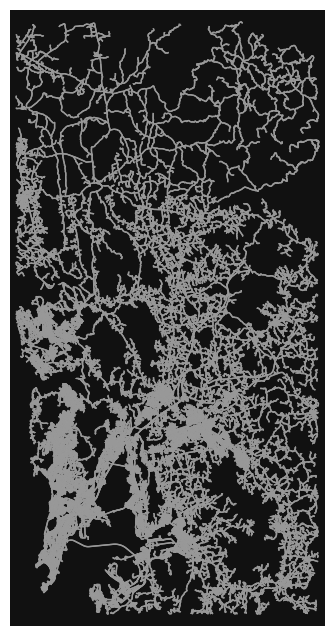

In [18]:
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import re
from difflib import get_close_matches

# -------------------------------------------------
# LOAD EXISTING DATA
# -------------------------------------------------

pois = pd.read_csv("railway_mumbai.csv")
G = ox.load_graphml("mumbai_graph.graphml")

# -------------------------------------------------
# 1️⃣ Normalization Function
# -------------------------------------------------

def normalize(name):
    name = str(name).lower().strip()
    name = re.sub(r"\(.*?\)", "", name)
    name = name.replace("junction", "")
    name = name.replace("jn", "")
    name = re.sub(r"\s+", " ", name)
    return name.strip()

# -------------------------------------------------
# 2️⃣ Load Rail Dataset
# -------------------------------------------------

df = pd.read_csv("Cleaned Local Train Dataset.csv")
df["station_clean"] = df["Station"].apply(normalize)

# Use time if exists, else assume 2 min per km
if "Time taken From Previous of the Line" in df.columns:
    df["rail_time"] = df["Time taken From Previous of the Line"]
else:
    df["rail_time"] = df["Distance From Previous of the Line"] * 2

# -------------------------------------------------
# 3️⃣ Build Rail Graph
# -------------------------------------------------

G_rail = nx.Graph()

for _, row in df.iterrows():
    G_rail.add_node(row["station_clean"], original=row["Station"])

for line, group in df.groupby("Line", sort=False):
    group = group.reset_index(drop=True)

    for i in range(1, len(group)):
        prev_station = group.loc[i - 1, "station_clean"]
        curr_station = group.loc[i, "station_clean"]
        time_weight = group.loc[i, "rail_time"]

        G_rail.add_edge(
            prev_station,
            curr_station,
            weight=time_weight,
            line=line
        )

rail_nodes = list(G_rail.nodes)

# -------------------------------------------------
# 4️⃣ Prepare Station Coordinates
# -------------------------------------------------

pois["station_clean"] = pois["name"].apply(normalize)
pois = pois[pois["station_clean"].isin(rail_nodes)].reset_index(drop=True)

poi_lookup = dict(
    zip(
        pois["station_clean"],
        zip(pois["latitude"], pois["longitude"])
    )
)

poi_names = pois["station_clean"].tolist()

def get_coordinates(station_clean):

    if station_clean in poi_lookup:
        return poi_lookup[station_clean]

    match = get_close_matches(station_clean, poi_names, n=1, cutoff=0.8)

    if match:
        return poi_lookup[match[0]]

    return None

# -------------------------------------------------
# 5️⃣ Select Source & Destination by Clicking
# -------------------------------------------------

fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0)

print("Click on SOURCE location")
src_point = plt.ginput(1)[0]

print("Click on DESTINATION location")
dst_point = plt.ginput(1)[0]

plt.close()

src_lon, src_lat = src_point
dst_lon, dst_lat = dst_point

src_node = ox.distance.nearest_nodes(G, src_lon, src_lat)
dst_node = ox.distance.nearest_nodes(G, dst_lon, dst_lat)

# -------------------------------------------------
# 6️⃣ Road Speed Assumption
# -------------------------------------------------

ROAD_SPEED_KMPH = 20
ROAD_TIME_PER_METER = 60 / (ROAD_SPEED_KMPH * 1000)

# -------------------------------------------------
# 7️⃣ Compute Nearest 3 Stations by Road Time
# -------------------------------------------------

def compute_nearest_3(start_node):

    results = []

    for station in rail_nodes:

        coords = get_coordinates(station)
        if coords is None:
            continue

        lat, lon = coords
        station_node = ox.distance.nearest_nodes(G, lon, lat)

        try:
            distance = nx.shortest_path_length(
                G,
                start_node,
                station_node,
                weight="length"
            )
        except:
            continue

        time_minutes = distance * ROAD_TIME_PER_METER
        results.append((station, time_minutes))

    results.sort(key=lambda x: x[1])
    return results[:3]

print("Computing nearest stations from source...")
nearest_src = compute_nearest_3(src_node)

print("Computing nearest stations from destination...")
nearest_dst = compute_nearest_3(dst_node)

# -------------------------------------------------
# 8️⃣ Evaluate Best Multimodal Route
# -------------------------------------------------

best_total_time = float("inf")
best_solution = None

for src_station, road_time_src in nearest_src:

    for dst_station, road_time_dst in nearest_dst:

        try:
            rail_time = nx.shortest_path_length(
                G_rail,
                src_station,
                dst_station,
                weight="weight"
            )
        except:
            continue

        total_time = road_time_src + rail_time + road_time_dst

        if total_time < best_total_time:
            best_total_time = total_time
            best_solution = (src_station, dst_station)

if best_solution is None:
    raise ValueError("No valid multimodal route found.")

src_station, dst_station = best_solution

rail_route = nx.shortest_path(
    G_rail,
    src_station,
    dst_station,
    weight="weight"
)

print("\nOptimal Multimodal Route:")
print("Source Station:", src_station.title())
print("Destination Station:", dst_station.title())
print("Estimated Total Time:", round(best_total_time, 2), "minutes")

# -------------------------------------------------
# 9️⃣ Plot Final Route
# -------------------------------------------------

fig, ax = ox.plot_graph(
    G,
    show=False,
    close=False,
    node_size=0,
    edge_color="lightgray",
    edge_linewidth=0.5
)

# Road segment: source → source station
coords = get_coordinates(src_station)
station_node = ox.distance.nearest_nodes(G, coords[1], coords[0])
road_path1 = nx.shortest_path(G, src_node, station_node, weight="length")

ox.plot_graph_route(
    G,
    road_path1,
    ax=ax,
    route_color="green",
    show=False,
    close=False
)

# Rail segment (straight line)
rail_lats = []
rail_lons = []

for st in rail_route:
    lat, lon = get_coordinates(st)
    rail_lats.append(lat)
    rail_lons.append(lon)

ax.plot(
    rail_lons,
    rail_lats,
    color="blue",
    linewidth=4
)

# Road segment: destination station → destination
coords = get_coordinates(dst_station)
station_node = ox.distance.nearest_nodes(G, coords[1], coords[0])
road_path2 = nx.shortest_path(G, station_node, dst_node, weight="length")

ox.plot_graph_route(
    G,
    road_path2,
    ax=ax,
    route_color="red",
    show=False,
    close=False
)

plt.title("Optimal Multimodal Route (Road + Rail)")
plt.show()
